In [4]:
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import torch

from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.datasets.lerobot_dataset import LeRobotDataset

plt.rcParams["figure.figsize"] = (10, 4)

/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
repo_id = "lerobot/pusht"

meta = LeRobotDatasetMetadata(repo_id)
print("repo_id:", repo_id)
print("fps:", meta.fps)
print("robot_type:", meta.robot_type)
print("total_episodes:", meta.total_episodes)
print("camera_keys:", meta.camera_keys)

print("\nfeatures(schema):")
pprint(meta.features)

repo_id: lerobot/pusht
fps: 10
robot_type: unknown
total_episodes: 206
camera_keys: ['observation.image']

features(schema):
{'action': {'dtype': 'float32',
            'fps': 10.0,
            'names': {'motors': ['motor_0', 'motor_1']},
            'shape': (2,)},
 'episode_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'frame_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.done': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.reward': {'dtype': 'float32', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.success': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'observation.image': {'dtype': 'video',
                       'names': ['height', 'width', 'channel'],
                       'shape': (96, 96, 3),
                       'video_info': {'has_audio': False,
                                      'video.codec': 'av

In [6]:
ds = LeRobotDataset(repo_id)
print("num_episodes:", ds.num_episodes)
print("num_frames:", ds.num_frames)

sample = ds[0]
print("keys:", sorted(sample.keys()))

def brief(x):
    return {"shape": tuple(x.shape), "dtype": str(x.dtype), "min": float(x.min()), "max": float(x.max())}

for k in sorted(sample.keys()):
    v = sample[k]
    if isinstance(v, torch.Tensor):
        print(k, brief(v))

num_episodes: 206
num_frames: 25650
keys: ['action', 'episode_index', 'frame_index', 'index', 'next.done', 'next.reward', 'next.success', 'observation.image', 'observation.state', 'task', 'task_index', 'timestamp']
action {'shape': (2,), 'dtype': 'torch.float32', 'min': 71.0, 'max': 233.0}
episode_index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
frame_index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
next.done {'shape': (), 'dtype': 'torch.bool', 'min': 0.0, 'max': 0.0}
next.reward {'shape': (), 'dtype': 'torch.float32', 'min': 0.19029748439788818, 'max': 0.19029748439788818}
next.success {'shape': (), 'dtype': 'torch.bool', 'min': 0.0, 'max': 0.0}
observation.image {'shape': (3, 96, 96), 'dtype': 'torch.float32', 'min': 0.23137255012989044, 'max': 1.0}
observation.state {'shape': (2,), 'dtype': 'torch.float32', 'min': 97.0, 'max': 222.0}
task_index {'shape': (), 'dtype': 'torch.int

objc[69186]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1366643a8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x1617c87a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[69186]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1366643f8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x1617c87f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


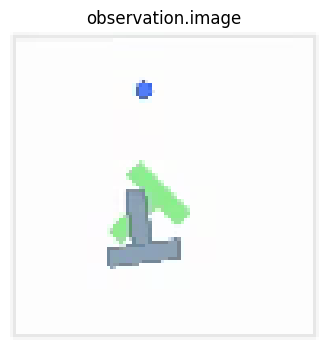

In [7]:
cam_key = ds.meta.camera_keys[0]  # 第一个相机
img = ds[0][cam_key]              # [C,H,W], torch tensor
img_np = img.permute(1, 2, 0).cpu().numpy()  # -> [H,W,C]

plt.imshow(img_np)
plt.title(cam_key)
plt.axis("off")
plt.show()


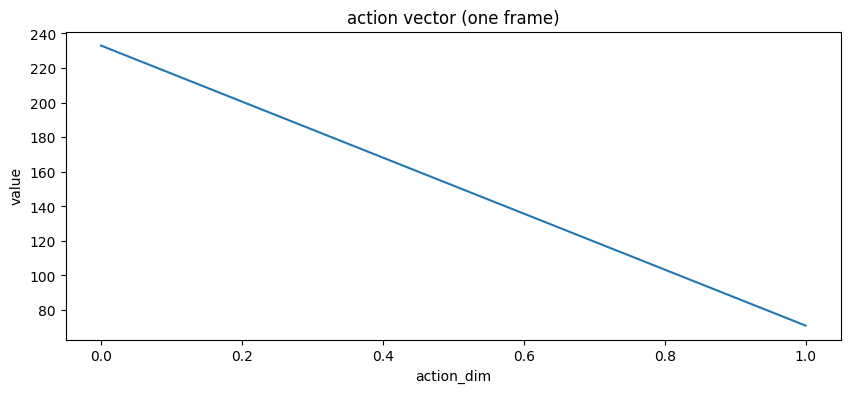

In [8]:
a = ds[0]["action"].cpu().numpy()  # 一帧的 action（通常是 action_dim）
plt.plot(a)
plt.title("action vector (one frame)")
plt.xlabel("action_dim")
plt.ylabel("value")
plt.show()

In [1]:
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import torch

from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.datasets.lerobot_dataset import LeRobotDataset

plt.rcParams["figure.figsize"] = (10, 4)

/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
repo_id = "lerobot/pusht"

meta = LeRobotDatasetMetadata(repo_id)
print("repo_id:", repo_id)
print("fps:", meta.fps)
print("robot_type:", meta.robot_type)
print("total_episodes:", meta.total_episodes)
print("camera_keys:", meta.camera_keys)

print("\nfeatures(schema):")
pprint(meta.features)

repo_id: lerobot/pusht
fps: 10
robot_type: unknown
total_episodes: 206
camera_keys: ['observation.image']

features(schema):
{'action': {'dtype': 'float32',
            'fps': 10.0,
            'names': {'motors': ['motor_0', 'motor_1']},
            'shape': (2,)},
 'episode_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'frame_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.done': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.reward': {'dtype': 'float32', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.success': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'observation.image': {'dtype': 'video',
                       'names': ['height', 'width', 'channel'],
                       'shape': (96, 96, 3),
                       'video_info': {'has_audio': False,
                                      'video.codec': 'av

In [3]:
ds = LeRobotDataset(repo_id)
print("num_episodes:", ds.num_episodes)
print("num_frames:", ds.num_frames)

sample = ds[0]
print("keys:", sorted(sample.keys()))

def brief(x):
    return {"shape": tuple(x.shape), "dtype": str(x.dtype), "min": float(x.min()), "max": float(x.max())}

for k in sorted(sample.keys()):
    v = sample[k]
    if isinstance(v, torch.Tensor):
        print(k, brief(v))

num_episodes: 206
num_frames: 25650
keys: ['action', 'episode_index', 'frame_index', 'index', 'next.done', 'next.reward', 'next.success', 'observation.image', 'observation.state', 'task', 'task_index', 'timestamp']
action {'shape': (2,), 'dtype': 'torch.float32', 'min': 71.0, 'max': 233.0}
episode_index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
frame_index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
index {'shape': (), 'dtype': 'torch.int64', 'min': 0.0, 'max': 0.0}
next.done {'shape': (), 'dtype': 'torch.bool', 'min': 0.0, 'max': 0.0}
next.reward {'shape': (), 'dtype': 'torch.float32', 'min': 0.19029748439788818, 'max': 0.19029748439788818}
next.success {'shape': (), 'dtype': 'torch.bool', 'min': 0.0, 'max': 0.0}
observation.image {'shape': (3, 96, 96), 'dtype': 'torch.float32', 'min': 0.23137255012989044, 'max': 1.0}
observation.state {'shape': (2,), 'dtype': 'torch.float32', 'min': 97.0, 'max': 222.0}
task_index {'shape': (), 'dtype': 'torch.int

objc[73238]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x13af543a8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x14f9cc7a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[73238]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x13af543f8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x14f9cc7f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


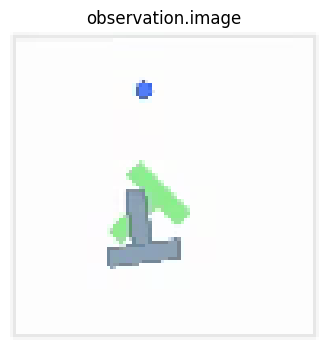

In [5]:
cam_key = ds.meta.camera_keys[0]  # 第一个相机
img = ds[0][cam_key]              # [C,H,W], torch tensor
img_np = img.permute(1, 2, 0).cpu().numpy()  # -> [H,W,C]

plt.imshow(img_np)
plt.title(cam_key)
plt.axis("off")
plt.show()

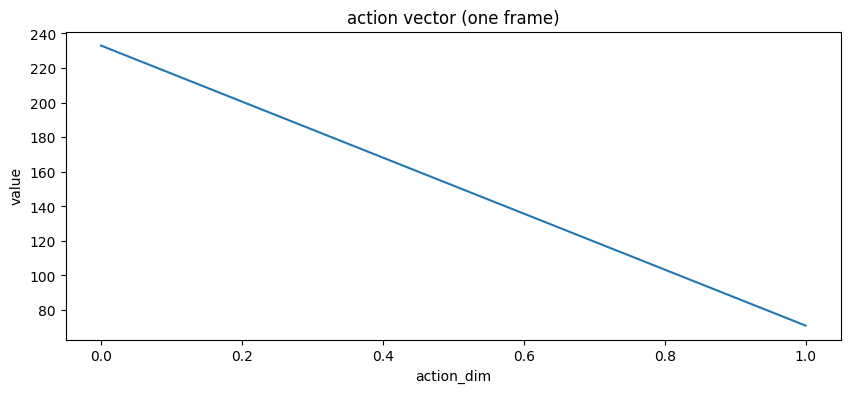

In [6]:
a = ds[0]["action"].cpu().numpy()  # 一帧的 action（通常是 action_dim）
plt.plot(a)
plt.title("action vector (one frame)")
plt.xlabel("action_dim")
plt.ylabel("value")
plt.show()

In [2]:
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
print(LeRobotDatasetMetadata("lerobot/pusht").features)

{'observation.image': {'dtype': 'video', 'shape': (96, 96, 3), 'names': ['height', 'width', 'channel'], 'video_info': {'video.fps': 10.0, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'has_audio': False}}, 'observation.state': {'dtype': 'float32', 'shape': (2,), 'names': {'motors': ['motor_0', 'motor_1']}, 'fps': 10.0}, 'action': {'dtype': 'float32', 'shape': (2,), 'names': {'motors': ['motor_0', 'motor_1']}, 'fps': 10.0}, 'episode_index': {'dtype': 'int64', 'shape': (1,), 'names': None, 'fps': 10.0}, 'frame_index': {'dtype': 'int64', 'shape': (1,), 'names': None, 'fps': 10.0}, 'timestamp': {'dtype': 'float32', 'shape': (1,), 'names': None, 'fps': 10.0}, 'next.reward': {'dtype': 'float32', 'shape': (1,), 'names': None, 'fps': 10.0}, 'next.done': {'dtype': 'bool', 'shape': (1,), 'names': None, 'fps': 10.0}, 'next.success': {'dtype': 'bool', 'shape': (1,), 'names': None, 'fps': 10.0}, 'index': {'dtype': 'int64', 'shape': (1,), 'names': None, 'fps': 10.0},

## ACT 训练：正常数据准备流程（对齐 `lerobot-train`）

**原理**：`ACTConfig.action_delta_indices` 默认是 `range(chunk_size)` → `resolve_delta_timestamps` 把「帧索引差」变成「秒偏移」→ `LeRobotDataset` 按这些偏移从 Parquet/视频里取出 **action 序列**，并在 episode 边界外打 **`action_is_pad`**。

```mermaid
flowchart LR
  A[ACTConfig.chunk_size] --> B[action_delta_indices]
  B --> C[resolve_delta_timestamps]
  C --> D[LeRobotDataset delta_timestamps]
  D --> E[__getitem__: action 形状 chunk x dim]
  D --> F[action_is_pad]
  E --> G[DataLoader batch]
  style A fill:#1e3a5f,color:#e6edf3
  style G fill:#1e3a5f,color:#e6edf3
```


In [3]:
# 与训练脚本相同：factory.resolve_delta_timestamps(policy_cfg, ds_meta)
from lerobot.datasets.factory import resolve_delta_timestamps
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.act.configuration_act import ACTConfig

REPO_ID = "lerobot/pusht"
ds_meta = LeRobotDatasetMetadata(REPO_ID)

act_cfg = ACTConfig()  # 默认 chunk_size=100 → 未来 100 步 action
delta_ts = resolve_delta_timestamps(act_cfg, ds_meta)
print("chunk_size =", act_cfg.chunk_size)
print("action 的 delta 帧索引 (前 5 个):", list(range(act_cfg.chunk_size))[:5], "...")
print("action 的 delta_timestamps 秒 (前 5 个):", [round(x, 4) for x in delta_ts["action"][:5]], "...")

ds_act = LeRobotDataset(REPO_ID, delta_timestamps=delta_ts)
sample = ds_act[0]
print("\n单条样本（训练时 policy 看到的大致形状）:")
for k in sorted(sample.keys()):
    v = sample[k]
    if hasattr(v, "shape"):
        print(f"  {k}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"  {k}: {type(v).__name__} = {v!r}")


objc[80210]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14a43c3a8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x1123607a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


chunk_size = 100
action 的 delta 帧索引 (前 5 个): [0, 1, 2, 3, 4] ...
action 的 delta_timestamps 秒 (前 5 个): [0.0, 0.1, 0.2, 0.3, 0.4] ...

单条样本（训练时 policy 看到的大致形状）:
  action: shape=(100, 2), dtype=torch.float32
  action_is_pad: shape=(100,), dtype=torch.bool
  episode_index: shape=(), dtype=torch.int64
  frame_index: shape=(), dtype=torch.int64
  index: shape=(), dtype=torch.int64
  next.done: shape=(), dtype=torch.bool
  next.reward: shape=(), dtype=torch.float32
  next.success: shape=(), dtype=torch.bool
  observation.image: shape=(3, 96, 96), dtype=torch.float32
  observation.state: shape=(2,), dtype=torch.float32
  task: str = 'Push the T-shaped block onto the T-shaped target.'
  task_index: shape=(), dtype=torch.int64
  timestamp: shape=(), dtype=torch.float32


objc[80210]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14a43c3f8) and /opt/anaconda3/envs/lerobot/lib/libavdevice.62.1.100.dylib (0x1123607f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_act, batch_size=4, shuffle=False, num_workers=0)
batch = next(iter(loader))
print("batch['action']:", batch["action"].shape)  # 期望 [B, chunk_size, action_dim]
print("batch['action_is_pad']:", batch["action_is_pad"].shape)
cam = ds_act.meta.camera_keys[0]
print(f"batch[{cam!r}]:", batch[cam].shape)  # 图像 [B, C, H, W]


In [ ]:
# 与 make_policy 一致：从 dataset features 填好 input/output_features，再建归一化流水线
from lerobot.configs.types import FeatureType
from lerobot.datasets.feature_utils import dataset_to_policy_features
from lerobot.policies.act.processor_act import make_act_pre_post_processors

features_pf = dataset_to_policy_features(ds_meta.features)
act_cfg_train = ACTConfig()
act_cfg_train.device = "cpu"
act_cfg_train.output_features = {k: v for k, v in features_pf.items() if v.type is FeatureType.ACTION}
act_cfg_train.input_features = {
    k: v for k, v in features_pf.items() if k not in act_cfg_train.output_features
}

preprocessor, postprocessor = make_act_pre_post_processors(
    act_cfg_train, dataset_stats=ds_meta.stats
)
print("Preprocessor 步骤:", [type(s).__name__ for s in preprocessor.steps])
print("stats 里有哪些键（用于 Normalizer）:", list(ds_meta.stats.keys())[:8], "...")


---
## ACT on pusht：完整训练数据流（step by step）

```mermaid
flowchart TD
  subgraph S1["Step 1 · 磁盘数据"]
    D1["Parquet: 每行=1帧\naction=[ax,ay] 单步"]
    D2["MP4: 96×96 RGB video"]
  end
  subgraph S2["Step 2 · Dataset 拼 Chunk"]
    E1["delta_timestamps=[0,0.1,...,9.9]s\n→ 取未来100步action"]
    E2["sample['action'] = [100,2]\nsample['action_is_pad'] = [100] bool"]
    E3["sample['observation.image'] = [3,96,96]\nsample['observation.state'] = [2]"]
  end
  subgraph S3["Step 3 · Normalize"]
    F1["state/action: (x-mean)/std\nimage: ImageNet mean/std"]
  end
  subgraph S4["Step 4 · ACT Forward (训练)"]
    G1["VAE Encoder:\n[CLS,state,a0..a99] → mu,logσ²\n→ sample z"]
    G2["ResNet18 Backbone:\nimage → feature_map [B,512,6,6]"]
    G3["Transformer Encoder:\n[z, state, *image_tokens] → context"]
    G4["Transformer Decoder:\n[100 query] × attention(context) → [B,100,2]"]
  end
  subgraph S5["Step 5 · Loss"]
    H1["L1 Loss: |a_gt - a_hat| * ~pad\nKL Loss: KL(q(z|s,a)||N(0,I))"]
    H2["total = L1 + 10 * KL"]
  end
  subgraph S6["Step 6 · Backward"]
    I1["loss.backward() → clip_grad → AdamW.step()"]
  end
  S1 --> S2 --> S3 --> S4 --> S5 --> S6
  style S1 fill:#1a2e4a,color:#c9d1d9
  style S2 fill:#1a2e4a,color:#c9d1d9
  style S3 fill:#1a2e4a,color:#c9d1d9
  style S4 fill:#1a2e4a,color:#c9d1d9
  style S5 fill:#1a2e4a,color:#c9d1d9
  style S6 fill:#1a2e4a,color:#c9d1d9
```


### Step 1 · pusht 磁盘数据长什么样

pusht 任务：机器人要把 T 形积木推到 T 形目标位置。

| 字段 | 形状 | 含义 |
|---|---|---|
| `observation.image` | `(96, 96, 3)` | 俯视图 RGB，fps=10 |
| `observation.state` | `(2,)` | 机器人末端 (x, y) |
| `action` | `(2,)` | 目标位置 (x, y)，**单帧** |

每个 episode ≈ 200 帧，全数据集共 206 个 episode、**24900 帧**。


原始单帧:
  observation.state: tensor([222.,  97.])
  action           : tensor([233.,  71.])
  observation.image: torch.Size([3, 96, 96])


/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20463 (\N{CJK UNIFIED IDEOGRAPH-4FEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/lerobot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

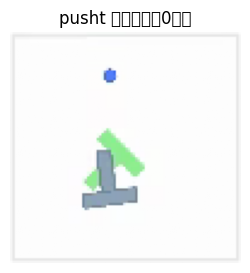

In [4]:
# Step 1: 看一条原始帧（无 chunk，单步 action）
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import torch, matplotlib.pyplot as plt

ds_raw = LeRobotDataset("lerobot/pusht")  # 无 delta_timestamps → action 是单步 [2]
raw = ds_raw[0]
print("原始单帧:")
print("  observation.state:", raw["observation.state"])   # [2]
print("  action           :", raw["action"])              # [2] 单步
print("  observation.image:", raw["observation.image"].shape)  # [3,96,96]

# 可视化当前帧
img = raw["observation.image"].permute(1,2,0).numpy()
plt.figure(figsize=(3,3))
plt.imshow(img)
plt.title("pusht 俯视图（第0帧）")
plt.axis("off")
plt.show()


### Step 2 · ACT 如何把单步 action 变成 action chunk

ACT 的核心思想：**不只预测下一步，而是一次预测未来 100 步**（Action Chunking）。

```
帧索引:    t    t+1   t+2  ...  t+99
           ↓    ↓     ↓          ↓
action: [ax,ay][ax,ay][ax,ay] ... [ax,ay]   → 拼成 [100, 2]
is_pad:  False  False  ...        True(边界外)
```

`resolve_delta_timestamps(ACTConfig(), ds_meta)` 把帧索引 [0,1,…,99] 变成秒偏移 [0, 0.1, 0.2, …, 9.9]，传给 `LeRobotDataset`。


In [6]:
# Step 2: 构建带 chunk 的 dataset
from lerobot.datasets.factory import resolve_delta_timestamps
from lerobot.policies.act.configuration_act import ACTConfig

act_cfg = ACTConfig()          # chunk_size=100
delta_ts = resolve_delta_timestamps(act_cfg, LeRobotDatasetMetadata("lerobot/pusht"))
ds_act = LeRobotDataset("lerobot/pusht", delta_timestamps=delta_ts)

s = ds_act[0]
print("action chunk 形状  :", s["action"].shape)          # [100, 2]
print("action_is_pad 形状 :", s["action_is_pad"].shape)   # [100]
print("pad 情况 (0=有效)  :", s["action_is_pad"].int())    # 第0帧开头，全0

# 看最后几帧（接近 episode 结尾，会有 pad）
last_ep0_idx = int(ds_act.meta.episodes[0]["dataset_to_index"]) - 1  # episode 0 最后一帧全局索引
s_last = ds_act[last_ep0_idx]
print("\n最后一帧的 is_pad  :", s_last["action_is_pad"].int()[:10], "... (从某位置开始为1)")


action chunk 形状  : torch.Size([100, 2])
action_is_pad 形状 : torch.Size([100])
pad 情况 (0=有效)  : tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0], dtype=torch.int32)

最后一帧的 is_pad  : tensor([0, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=torch.int32) ... (从某位置开始为1)


/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/1703494950.py:16: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/1703494950.py:16: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/1703494950.py:16: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/1703494950.py:16: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/1703494950.py:16: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu

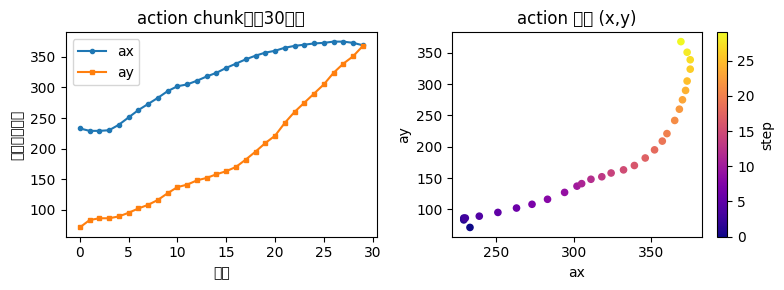

In [7]:
# 可视化 action chunk（前30步的 x/y 轨迹）
import matplotlib.pyplot as plt
chunk = s["action"][:30].numpy()   # [30, 2]
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(chunk[:, 0], label="ax", marker="o", ms=3)
plt.plot(chunk[:, 1], label="ay", marker="s", ms=3)
plt.legend(); plt.title("action chunk（前30步）")
plt.xlabel("步数"); plt.ylabel("归一化前坐标")

plt.subplot(1, 2, 2)
plt.scatter(chunk[:, 0], chunk[:, 1], c=range(30), cmap="plasma", s=20)
plt.colorbar(label="step")
plt.title("action 轨迹 (x,y)")
plt.xlabel("ax"); plt.ylabel("ay")
plt.tight_layout(); plt.show()


### Step 3 · DataLoader → batch

训练脚本里 `DataLoader(dataset, batch_size=8, shuffle=True)` 把多个样本拼成 batch：

| tensor | 形状 |
|---|---|
| `observation.image` | `[B, 3, 96, 96]` |
| `observation.state` | `[B, 2]` |
| `action` | `[B, 100, 2]` |
| `action_is_pad` | `[B, 100]` |


In [8]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_act, batch_size=4, shuffle=False, num_workers=0)
batch = next(iter(loader))
print("=== 一个 batch 的所有 tensor ===")
for k, v in sorted(batch.items()):
    if hasattr(v, "shape"):
        print(f"  {k:40s}: {tuple(v.shape)}")


=== 一个 batch 的所有 tensor ===
  action                                  : (4, 100, 2)
  action_is_pad                           : (4, 100)
  episode_index                           : (4,)
  frame_index                             : (4,)
  index                                   : (4,)
  next.done                               : (4,)
  next.reward                             : (4,)
  next.success                            : (4,)
  observation.image                       : (4, 3, 96, 96)
  observation.state                       : (4, 2)
  task_index                              : (4,)
  timestamp                               : (4,)


### Step 4 · ACT 模型内部（Forward Pass）

**训练时走三条路**：

```mermaid
flowchart LR
  A["action chunk\n[B,100,2]"] --> VAE
  ST["state\n[B,2]"] --> VAE
  subgraph VAE["VAE Encoder（只训练用）"]
    V1["Linear proj → dim_model"]
    V2["拼 CLS token\n序列=[CLS,state,a0..a99]\n共 102 tokens"]
    V3["4层 Transformer Encoder"]
    V4["CLS输出 → Linear → mu,logσ²\n各 [B,32]"]
    V5["重参数化: z=mu+σ·ε"]
    V1-->V2-->V3-->V4-->V5
  end
  IMG["image\n[B,3,96,96]"] --> BB
  subgraph BB["ResNet18 Backbone"]
    B1["layer4 feature_map\n[B,512,6,6]"]
    B2["1×1 Conv → [B,512,6,6]"]
    B3["reshape → [36,B,512]"]
    B1-->B2-->B3
  end
  VAE --> ENC
  ST --> ENC
  BB --> ENC
  subgraph ENC["Transformer Encoder"]
    E1["tokens = [z, state, img×36]\n共 38 tokens, 4层 self-attn"]
    E2["encoder_out [38,B,512]"]
    E1-->E2
  end
  subgraph DEC["Transformer Decoder"]
    D1["query: 100个可学习位置嵌入\n[100,B,512]"]
    D2["cross-attn(query, encoder_out)\n1层 decoder"]
    D3["Linear → [B,100,2]\n预测 action chunk"]
    D1-->D2-->D3
  end
  ENC --> DEC
  style VAE fill:#1a3a5c,color:#c9d1d9
  style BB fill:#1a3a5c,color:#c9d1d9
  style ENC fill:#1a3a5c,color:#c9d1d9
  style DEC fill:#1a3a5c,color:#c9d1d9
```


In [9]:
# Step 4: 把 batch 喂给 ACTPolicy，看输出形状
import torch
from lerobot.configs.types import FeatureType
from lerobot.datasets.feature_utils import dataset_to_policy_features
from lerobot.policies.act.modeling_act import ACTPolicy

ds_meta_local = LeRobotDatasetMetadata("lerobot/pusht")
features_pf = dataset_to_policy_features(ds_meta_local.features)

act_cfg2 = ACTConfig()
act_cfg2.device = "cpu"
act_cfg2.pretrained_backbone_weights = None  # 避免下载
act_cfg2.output_features = {k: v for k, v in features_pf.items() if v.type is FeatureType.ACTION}
act_cfg2.input_features = {k: v for k, v in features_pf.items() if k not in act_cfg2.output_features}

policy = ACTPolicy(config=act_cfg2)
policy.train()

# 构造最小 batch（不做归一化，只看形状）
B = 2
mini_batch = {
    "observation.image": torch.randn(B, 3, 96, 96),
    "observation.state": torch.randn(B, 2),
    "action": torch.randn(B, 100, 2),
    "action_is_pad": torch.zeros(B, 100, dtype=torch.bool),
}

loss, loss_dict = policy.forward(mini_batch)
print("loss     :", loss.item())
print("loss_dict:", {k: round(v, 4) for k, v in loss_dict.items()})


loss     : 83.37161254882812
loss_dict: {'l1_loss': 0.8751, 'kld_loss': 8.2497}


---
## 深入解析：Transformer Encoder + Decoder

### 整体分工

```mermaid
flowchart TD
  subgraph ENC_INPUT["Encoder 输入（38 tokens）"]
    T0["z token [1]\n= VAE采样的隐变量"]
    T1["state token [1]\n= agent当前坐标"]
    T2["image tokens [36]\n= ResNet18特征图展平"]
  end
  subgraph ENC["Transformer Encoder（4层 Self-Attention）"]
    E1["所有38个token互相看\nQ=K=x+pos, V=x"]
    E2["输出: context [38,B,512]"]
    E1-->E2
  end
  subgraph DEC_INPUT["Decoder 输入（100 queries）"]
    Q["100个零向量\n+ 100个可学习位置嵌入\n= '我要第i步的动作'"]
  end
  subgraph DEC["Transformer Decoder（1层）"]
    D1["① queries 互相 self-attn\n学习步间协调"]
    D2["② cross-attn 问 encoder\n从 context 提取每步内容"]
    D3["③ FFN"]
    D1-->D2-->D3
  end
  ENC_INPUT --> ENC
  ENC --> DEC
  DEC_INPUT --> DEC
  DEC --> HEAD["Linear(512→2)\n→ action chunk [B,100,2]"]
  style ENC_INPUT fill:#1a2e4a,color:#c9d1d9
  style ENC fill:#1a2e4a,color:#c9d1d9
  style DEC_INPUT fill:#1a2e4a,color:#c9d1d9
  style DEC fill:#1a2e4a,color:#c9d1d9
```


### Encoder 详解：38 个 token 如何构造与运算

| token | 形状 | 来源 | 位置编码 |
|---|---|---|---|
| z | `[1,B,512]` | VAE隐变量→Linear(32,512) | 可学习 index 0 |
| state | `[1,B,512]` | [ax,ay]→Linear(2,512) | 可学习 index 1 |
| image×36 | `[36,B,512]` | ResNet layer4→1×1conv→reshape | 2D正弦 |

**每层 EncoderLayer 结构（源码 550-568 行）**：
```python
# 位置编码只加在 Q 和 K，V 不加
q = k = x + pos_embed
x = SelfAttention(Q=q, K=k, V=x) + x  # 残差
x = LayerNorm(x)
x = FFN(x) + x                         # FFN: 512→3200→512
x = LayerNorm(x)
```
4层之后，每个 token 都融合了所有 token 的信息。


In [ ]:
# 演示 Encoder 38 个 token 的构造
import torch, torch.nn as nn

B, dim_model, latent_dim = 2, 512, 32

z_sample  = torch.randn(B, latent_dim)       # VAE 输出
state     = torch.randn(B, 2)                # 归一化坐标
feat_map  = torch.randn(B, dim_model, 6, 6)  # ResNet layer4 → 1×1conv 后

z_proj    = nn.Linear(latent_dim, dim_model)
state_proj= nn.Linear(2, dim_model)

z_tok     = z_proj(z_sample).unsqueeze(0)              # [1, B, 512]
state_tok = state_proj(state).unsqueeze(0)             # [1, B, 512]
img_toks  = feat_map.flatten(2).permute(2,0,1)         # [36, B, 512]

enc_in = torch.cat([z_tok, state_tok, img_toks], dim=0)  # [38, B, 512]
print("Encoder 输入:")
print(f"  token[0]    = z       : {tuple(z_tok.shape)}")
print(f"  token[1]    = state   : {tuple(state_tok.shape)}")
print(f"  token[2-37] = image   : {tuple(img_toks.shape)}  (6×6=36)")
print(f"  拼接后                : {tuple(enc_in.shape)}")

# 1层 Encoder 后（简化版）
enc_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8, dim_feedforward=3200, batch_first=False)
enc_out = enc_layer(enc_in)
print(f"\nEncoder 输出            : {tuple(enc_out.shape)}  形状不变，但每个token已融合全局信息")


### Decoder 详解：100 个 query 怎么「问」context

**输入是全零 + 可学习位置嵌入（源码 493-503 行）**：
```python
decoder_in = torch.zeros(chunk_size, B, dim_model)  # 内容为空
# 每个 query 的「身份」来自：
decoder_pos_embed = nn.Embedding(chunk_size, dim_model)  # 100个可学习向量
```

**DecoderLayer 三步（源码 635-663 行）**：
```python
# ① Self-Attention：queries 互相协调
q = k = x + decoder_pos   # 每个query知道自己是第几步
x = SelfAttn(Q=q, K=k, V=x) + x

# ② Cross-Attention：从 encoder context 里取内容
x = CrossAttn(
    query = x + decoder_pos,         # 「我是第i步，我想要什么」
    key   = encoder_out + enc_pos,   # 「encoder各token在哪」
    value = encoder_out,             # 「encoder各token的内容（不加位置）」
) + x

# ③ FFN
x = FFN(x) + x
```

**最终输出**：`[100, B, 512]` → transpose → `[B, 100, 512]` → `Linear(512, 2)` → `[B, 100, 2]`


① Self-Attn  输出: (10, 2, 64)  queries 互相协调
② Cross-Attn 输出: (10, 2, 64)  从 context 提取内容
   cross-attn weights: (2, 10, 8)  = [B, 10 queries, 8 encoder tokens]


/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_97578/703512385.py:43: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_97578/703512385.py:43: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_97578/703512385.py:43: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_97578/703512385.py:43: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_97578/703512385.py:43: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2

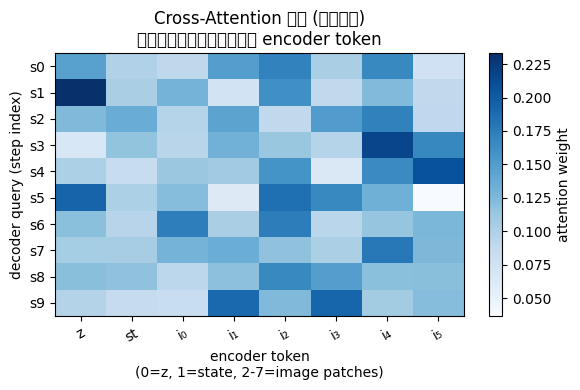

In [1]:
# 演示 Decoder 三步
import torch, torch.nn as nn, matplotlib.pyplot as plt

B, chunk_size, dim_model = 2, 10, 64  # 简化
enc_len = 8

dec_in      = torch.zeros(chunk_size, B, dim_model)      # 全零内容
dec_pos_emb = nn.Embedding(chunk_size, dim_model)
dec_pos     = dec_pos_emb.weight.unsqueeze(1).expand(-1, B, -1)  # [10,B,64]

enc_out = torch.randn(enc_len, B, dim_model)              # encoder context
enc_pos = torch.randn(enc_len, B, dim_model)

self_attn  = nn.MultiheadAttention(dim_model, num_heads=4)
cross_attn = nn.MultiheadAttention(dim_model, num_heads=4)

# ① Self-Attention
x = dec_in
q = k = x + dec_pos
x2, _ = self_attn(q, k, x)
x = x + x2
print(f"① Self-Attn  输出: {tuple(x.shape)}  queries 互相协调")

# ② Cross-Attention
x2, w_cross = cross_attn(
    query = x + dec_pos,
    key   = enc_out + enc_pos,
    value = enc_out,
)
x = x + x2
print(f"② Cross-Attn 输出: {tuple(x.shape)}  从 context 提取内容")

# 可视化 cross-attention 权重 [B, query, key]
print(f"   cross-attn weights: {tuple(w_cross.shape)}  = [B, 10 queries, 8 encoder tokens]")
plt.figure(figsize=(6, 4))
plt.imshow(w_cross[0].detach().numpy(), aspect="auto", cmap="Blues")
plt.colorbar(label="attention weight")
plt.xlabel("encoder token\n(0=z, 1=state, 2-7=image patches)")
plt.ylabel("decoder query (step index)")
plt.title("Cross-Attention 权重 (初始随机)\n训练后每步会学会关注哪些 encoder token")
plt.xticks(range(8), ["z","st","i₀","i₁","i₂","i₃","i₄","i₅"], rotation=30)
plt.yticks(range(chunk_size), [f"s{i}" for i in range(chunk_size)])
plt.tight_layout()
plt.show()


In [ ]:
# 完整推理：ACT model forward（推理时 z=0）
import torch
from lerobot.policies.act.modeling_act import ACT
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.datasets.feature_utils import dataset_to_policy_features
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
from lerobot.configs.types import FeatureType
from lerobot.utils.constants import OBS_IMAGES, OBS_STATE

ds_meta     = LeRobotDatasetMetadata("lerobot/pusht")
features_pf = dataset_to_policy_features(ds_meta.features)

cfg = ACTConfig()
cfg.device = "cpu"
cfg.pretrained_backbone_weights = None
cfg.output_features = {k: v for k, v in features_pf.items() if v.type is FeatureType.ACTION}
cfg.input_features  = {k: v for k, v in features_pf.items() if k not in cfg.output_features}

model = ACT(cfg).eval()

B = 1
batch = {
    OBS_IMAGES: [torch.randn(B, 3, 96, 96)],  # 1个相机
    OBS_STATE:  torch.randn(B, 2),
    # 推理时无 action → z 自动设为全零
}

with torch.no_grad():
    actions, (mu, sigma) = model(batch)

print("=== 完整推理 forward ===")
print(f"input image  : {tuple(batch[OBS_IMAGES][0].shape)}")
print(f"input state  : {tuple(batch[OBS_STATE].shape)}")
print(f"z (全零)     : [{B}, {cfg.latent_dim}]")
print(f"output action: {tuple(actions.shape)}  = [B, 100 steps, 2 dims]")
print(f"\n前5步预测动作 (归一化坐标):")
for i, a in enumerate(actions[0, :5].tolist()):
    print(f"  step {i}: ({a[0]:.3f}, {a[1]:.3f})")


### 关键设计问题解答

| 问题 | 答案 |
|---|---|
| Decoder 输入为什么是全零？ | 零只是空容器，真正的 identity 来自可学习位置嵌入，类似 DETR 的 object queries |
| V 为什么不加位置编码？ | Q×K 决定「去哪取」（需要位置），V 是「取到的内容」（不应被位置污染） |
| n_decoder_layers=1 不会太少吗？ | 原始 ACT 论文有 bug 导致实际只用1层，这里刻意复现，实验证明1层已足够 |
| 图像为什么是 36 个 token？ | ResNet18 输出 6×6 feature map，展平成 36，每个对应 16×16 像素感受野 |
| Encoder 4 层 vs Decoder 1 层？ | Encoder 负责「理解」，需要多层充分融合；Decoder 只需1次 cross-attn 提取即可 |


### Step 5 · Loss 计算

来自 `modeling_act.py` 第 136-162 行：

```python
# L1 Loss：只对非 pad 的步算误差
l1_loss = (|action_gt - action_hat| * ~action_is_pad).mean()

# KL Loss：让 VAE latent 靠近标准正态
kld = -0.5 * (1 + logσ² - μ² - exp(logσ²)).sum(-1).mean()

# 总 Loss
total = l1_loss + kl_weight(=10) * kld
```

**为什么用 L1 不用 L2？** L1 对离群值更鲁棒，机器人运动轨迹里偶尔出现大偏差时不会爆炸。

**为什么要 KL Loss？** 让 latent `z` 不要随便乱跑，推理时可以用 `z=0` 代替 VAE 编码。


In [ ]:
# 演示 is_pad 如何影响 Loss（episode 末尾 pad 部分不计入）
import torch
import torch.nn.functional as F

B, chunk, dim = 2, 10, 2
action_gt  = torch.zeros(B, chunk, dim)
action_hat = torch.ones(B, chunk, dim)  # 全预测成1，误差=1

# 场景1：无 pad
is_pad_none = torch.zeros(B, chunk, dtype=torch.bool)
loss_full = (F.l1_loss(action_gt, action_hat, reduction="none") * ~is_pad_none.unsqueeze(-1)).mean()
print("无 pad 时 L1:", loss_full.item())  # 1.0

# 场景2：后5步是 pad
is_pad_half = torch.zeros(B, chunk, dtype=torch.bool)
is_pad_half[:, 5:] = True
loss_half = (F.l1_loss(action_gt, action_hat, reduction="none") * ~is_pad_half.unsqueeze(-1)).mean()
print("后5步 pad L1:", loss_half.item())  # 约 0.5（pad部分不算）


---
## VAE Encoder 输入数据如何构造（逐步图解）

**来源**：经过 Normalizer 归一化之后的 `batch`，只用到 3 个字段：

| 字段 | 形状 | 归一化方式 |
|---|---|---|
| `observation.state` | `[B, 2]` | MEAN_STD（均值 0，标准差 1） |
| `action` | `[B, 100, 2]` | MEAN_STD |
| `action_is_pad` | `[B, 100]` bool | 不归一化 |

> **注意：图像不进 VAE Encoder！** VAE Encoder 只关心「这段 action 长什么样」，不看图。

### 构造流程（对应 modeling_act.py 第 407-435 行）

```mermaid
flowchart TD
  subgraph INPUT["原始输入（归一化后）"]
    S["state [B,2]"] 
    A["action [B,100,2]"]
    P["action_is_pad [B,100]"]
  end
  subgraph PROJ["步骤1：升维到 dim_model=512"]
    CLS["CLS token\nnn.Embedding(1,512)\n→ broadcast → [B,1,512]"]
    SP["state → Linear(2,512)\n→ unsqueeze → [B,1,512]"]
    AP["action → Linear(2,512)\n→ [B,100,512]"]
  end
  subgraph CAT["步骤2：拼接为序列"]
    SEQ["torch.cat([CLS,state,action], dim=1)\n→ [B, 102, 512]"]
  end
  subgraph PE["步骤3：加位置编码"]
    POS["固定正弦位置编码 [1,102,512]\n告诉模型 token 0=CLS, 1=state, 2-101=action"]
  end
  subgraph MASK["步骤4：构造 PAD mask"]
    M["[False, False, pad_0,pad_1,...,pad_99]\n[B, 102]  True=忽略这个token"]
  end
  INPUT --> PROJ
  PROJ --> CAT
  CAT --> PE
  P --> MASK
  style INPUT fill:#1a2e4a,color:#c9d1d9
  style PROJ fill:#1a2e4a,color:#c9d1d9
  style CAT fill:#1a2e4a,color:#c9d1d9
  style PE fill:#1a2e4a,color:#c9d1d9
  style MASK fill:#1a2e4a,color:#c9d1d9
```


In [ ]:
# === VAE Encoder 输入构造全流程 ===
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

B          = 4    # batch size
chunk_size = 100  # action chunk 长度
action_dim = 2    # pusht: (ax, ay)
state_dim  = 2    # pusht: (sx, sy)
dim_model  = 512  # Transformer 隐层宽度

# ------ 原始输入（假设已经过 Normalizer，值域约 [-3, 3]）------
state        = torch.randn(B, state_dim)              # [B, 2]
action_chunk = torch.randn(B, chunk_size, action_dim) # [B, 100, 2]
action_is_pad = torch.zeros(B, chunk_size, dtype=torch.bool)
action_is_pad[:, 85:] = True   # 最后 15 步超出 episode 边界

print("===== 原始输入 =====")
print(f"state          : {tuple(state.shape)}")
print(f"action_chunk   : {tuple(action_chunk.shape)}")
print(f"action_is_pad  : {tuple(action_is_pad.shape)}, pad 步数 = {action_is_pad[0].sum().item()}")


In [ ]:
# 步骤 1：三路升维到 dim_model=512

# ① CLS token：nn.Embedding(1, 512) → 广播到 B 个
#   每个 batch 用同一个可学习向量，作用是「接收整个序列的摘要」
cls_embed_layer = nn.Embedding(1, dim_model)
cls_embed = cls_embed_layer.weight.unsqueeze(0).expand(B, -1, -1).clone()  # [B, 1, 512]

# ② state：Linear(2, 512)，每帧只有 1 个 state token
state_proj = nn.Linear(state_dim, dim_model)
state_embed = state_proj(state).unsqueeze(1)   # [B, 2] → [B, 512] → [B, 1, 512]

# ③ action chunk：Linear(2, 512)，100 步各自映射
action_proj = nn.Linear(action_dim, dim_model)
action_embed = action_proj(action_chunk)        # [B, 100, 2] → [B, 100, 512]

print("===== 步骤1：升维 =====")
print(f"① CLS embed   : {tuple(cls_embed.shape)}")
print(f"② state embed : {tuple(state_embed.shape)}")
print(f"③ action embed: {tuple(action_embed.shape)}")

# 步骤 2：拼成序列 [CLS, state, a0, a1, ..., a99]
seq = torch.cat([cls_embed, state_embed, action_embed], dim=1)  # [B, 102, 512]
print(f"\n步骤2 拼接序列 : {tuple(seq.shape)}  = [B, 1+1+100, 512]")
print("  token 0    = CLS")
print("  token 1    = state")
print("  token 2-101= action step 0-99")


In [ ]:
# 步骤 3：固定正弦位置编码（来自 create_sinusoidal_pos_embedding）
# 公式：PE[pos, 2i]   = sin(pos / 10000^(2i/d))
#        PE[pos, 2i+1] = cos(pos / 10000^(2i/d))

def make_sinusoidal_pos_enc(num_pos, d_model):
    pos = np.arange(num_pos)[:, np.newaxis]         # [T, 1]
    i   = np.arange(d_model)[np.newaxis, :]         # [1, D]
    angle = pos / np.power(10000, 2 * (i // 2) / d_model)
    angle[:, 0::2] = np.sin(angle[:, 0::2])         # 偶数维 sin
    angle[:, 1::2] = np.cos(angle[:, 1::2])         # 奇数维 cos
    return torch.tensor(angle, dtype=torch.float32)  # [T, D]

num_tokens = 1 + 1 + chunk_size  # CLS + state + 100 actions = 102
pos_enc = make_sinusoidal_pos_enc(num_tokens, dim_model)  # [102, 512]
print(f"步骤3 位置编码形状: {tuple(pos_enc.shape)}")
print("  每行 = 一个 token 的位置编码")
print("  前几行 (token 0,1,2):")
print("  token0 (CLS)  :", pos_enc[0, :4].tolist())
print("  token1 (state):", pos_enc[1, :4].tolist())
print("  token2 (a₀)   :", pos_enc[2, :4].tolist())

# 可视化位置编码热图（前 20 个 token，前 64 个维度）
plt.figure(figsize=(10, 3))
plt.imshow(pos_enc[:20, :64].numpy(), aspect="auto", cmap="RdBu")
plt.colorbar()
plt.xlabel("维度 (前64)")
plt.ylabel("token 位置")
plt.yticks([0,1,2,10,19], ["CLS","state","a₀","a₈","a₁₇"])
plt.title("正弦位置编码热图（每行=一个token的位置信息）")
plt.tight_layout()
plt.show()


In [ ]:
# 步骤 4：构造 PAD mask
# 规则：CLS 和 state 永远不 mask（False）；action 部分用 action_is_pad

cls_state_no_pad = torch.zeros(B, 2, dtype=torch.bool)  # [B, 2]  全 False
key_padding_mask = torch.cat([cls_state_no_pad, action_is_pad], dim=1)  # [B, 102]

print("步骤4 PAD mask形状:", tuple(key_padding_mask.shape))
print("  token  0 (CLS)  :", key_padding_mask[0, 0].item(),  " ← False=参与attention")
print("  token  1 (state):", key_padding_mask[0, 1].item(),  " ← False=参与attention")
print("  token  2 (a₀)   :", key_padding_mask[0, 2].item(),  " ← False=有效action")
print("  token 86 (a₈₄)  :", key_padding_mask[0, 87].item(), " ← True=越界,忽略")
print("  token101 (a₉₉)  :", key_padding_mask[0, 101].item()," ← True=越界,忽略")

# 可视化 mask（4个样本的102个token）
plt.figure(figsize=(10, 2))
plt.imshow(key_padding_mask.numpy(), aspect="auto", cmap="RdYlGn_r")
plt.xlabel("token 索引 (0=CLS, 1=state, 2-101=action步)")
plt.ylabel("batch")
plt.title("PAD mask（绿=参与attention，红=被屏蔽）")
plt.axvline(1.5, color="white", lw=2, linestyle="--")
plt.text(0.5, -0.6, "CLS+state", ha="center", color="white", fontsize=8)
plt.text(50, -0.6, "action steps", ha="center", color="white", fontsize=8)
plt.colorbar(label="True=mask")
plt.tight_layout()
plt.show()


In [ ]:
# 步骤 5：送入 Transformer 前的最终形态
# ACT 的 Transformer 期望 [seq_len, B, dim]（非 batch_first）
# 所以需要 permute

seq_final     = seq.permute(1, 0, 2)      # [B,102,512] → [102, B, 512]
pos_enc_final = pos_enc.unsqueeze(1).expand(-1, B, -1)  # [102, B, 512]

print("===== 送入 Transformer 前的最终形态 =====")
print(f"seq (token序列+位置编码): {tuple(seq_final.shape)}  [seq_len, B, dim]")
print(f"pos_embed               : {tuple(pos_enc_final.shape)}")
print(f"key_padding_mask        : {tuple(key_padding_mask.shape)}  [B, seq_len]")
print()
print("Transformer 内部：")
print("  Q = K = token序列 + 位置编码  （位置编码加在 Q 和 K 上，不加在 V 上）")
print("  V = token序列（无位置编码）")
print("  mask 屏蔽越界 action → CLS 输出不受 pad 影响")
print()
print("输出：取 seq[0] → CLS token → [B, 512]")
print("      → Linear(512, 64) → [mu:32, logσ²:32]")
print("      → z = mu + exp(logσ²/2) * ε  [B, 32]")


### 为什么这样构造？——每个设计的原因

| 设计 | 原因 |
|---|---|
| **用 CLS token 汇聚信息** | 类似 BERT。CLS 与所有 token 做 self-attention，最终输出自然包含整段序列摘要 |
| **action 和 state 一起送入** | z 要表达「在当前状态下，这段 action 的风格」，所以状态也是条件 |
| **图像不进 VAE Encoder** | 图像特征大（36 tokens），且 z 只是描述「动作风格」而非「看到什么」；加入图像会让 VAE 过拟合具体环境 |
| **固定正弦位置编码（不可学习）** | 位置信息稳定可靠，不需要学习；而且 token 数固定（102），直接 precompute |
| **PAD mask 屏蔽越界 action** | episode 末尾超界的 action 是填充值，不能让 CLS 依赖它，否则 z 会被噪声污染 |
| **只取 CLS 的输出** | 其他位置输出的是各步 action 的「上下文向量」，CLS 是全局摘要，专门用来表示分布参数 |


### 为什么这样构造？——每个设计的原因

| 设计 | 原因 |
|---|---|
| **用 CLS token 汇聚信息** | 类似 BERT。CLS 与所有 token 做 self-attention，最终输出自然包含整段序列摘要 |
| **action 和 state 一起送入** | z 要表达「在当前状态下，这段 action 的风格」，所以状态也是条件 |
| **图像不进 VAE Encoder** | 图像特征大（36 tokens），且 z 只是描述「动作风格」而非「看到什么」；加入图像会让 VAE 过拟合具体环境 |
| **固定正弦位置编码（不可学习）** | 位置信息稳定可靠，不需要学习；而且 token 数固定（102），直接 precompute |
| **PAD mask 屏蔽越界 action** | episode 末尾超界的 action 是填充值，不能让 CLS 依赖它，否则 z 会被噪声污染 |
| **只取 CLS 的输出** | 其他位置输出的是各步 action 的「上下文向量」，CLS 是全局摘要，专门用来表示分布参数 |


---
## 坐标数据是如何编码进 VAE Encoder 的？为什么有效？

### 整个过程分两个阶段

```mermaid
flowchart LR
  subgraph RAW["原始坐标（像素空间）"]
    R1["state: [ax,ay]\n值域 [0,512]"]
    R2["action: [tx,ty]×100\n值域 [0,512]"]
  end
  subgraph NORM["阶段1：归一化\n（Preprocessor）"]
    N1["(x - mean) / std\n→ 值域约 [-2, 2]"]
  end
  subgraph PROJ["阶段2：线性投影\n（VAE Encoder 内部）"]
    P1["nn.Linear(2 → 512)\n每个神经元=一种坐标的线性组合"]
    P2["输出 512 个特征\n= 512 种不同的'坐标描述方式'"]
  end
  subgraph ATTN["阶段3：Transformer 推理"]
    A1["102 tokens 互相 attention\n学习 state-action 之间的关系"]
  end
  RAW --> NORM --> PROJ --> ATTN
  style RAW fill:#1a2e4a,color:#c9d1d9
  style NORM fill:#1a2e4a,color:#c9d1d9
  style PROJ fill:#1a2e4a,color:#c9d1d9
  style ATTN fill:#1a2e4a,color:#c9d1d9
```


In [ ]:
# === 阶段1：归一化 ===
# 先看 pusht 数据集的真实统计量
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata
import torch

meta = LeRobotDatasetMetadata("lerobot/pusht")
stats = meta.stats

print("=== pusht 数据集真实统计量 ===")
for key in ["observation.state", "action"]:
    print(f"\n{key}:")
    print(f"  mean = {stats[key]['mean'].tolist()}")
    print(f"  std  = {stats[key]['std'].tolist()}")
    print(f"  min  = {stats[key]['min'].tolist()}")
    print(f"  max  = {stats[key]['max'].tolist()}")

# 模拟归一化过程
raw_state  = torch.tensor([256.0, 400.0])   # 机器人在中间偏下
raw_action = torch.tensor([256.0, 256.0])   # 目标是正中心

state_mean = stats["observation.state"]["mean"]
state_std  = stats["observation.state"]["std"]
action_mean = stats["action"]["mean"]
action_std  = stats["action"]["std"]

norm_state  = (raw_state  - state_mean)  / state_std
norm_action = (raw_action - action_mean) / action_std

print("\n=== 归一化示例 ===")
print(f"原始 state  : {raw_state.tolist()}")
print(f"归一化 state: {norm_state.round(decimals=3).tolist()}")
print(f"原始 action : {raw_action.tolist()}")
print(f"归一化 action: {norm_action.round(decimals=3).tolist()}")
print("\n归一化后值域约 [-2, 2]，对梯度下降友好")


In [ ]:
# === 阶段2：Linear(2, 512) 做了什么 ===
# 核心：每个输出神经元 h_i = w_i0 * x + w_i1 * y + b_i
# 512 个神经元 = 512 种不同的「坐标描述方式」

import torch, torch.nn as nn, matplotlib.pyplot as plt

torch.manual_seed(42)
proj = nn.Linear(2, 512)

# 看权重的含义
W = proj.weight.detach()   # [512, 2]
print(f"投影矩阵形状: {tuple(W.shape)}")
print(f"每行 = 一个神经元对 (x,y) 的响应方向")
print(f"前5个神经元的权重 (wi0=x权重, wi1=y权重):")
for i in range(5):
    print(f"  神经元{i}: [{W[i,0]:.3f}, {W[i,1]:.3f}]  → h = {W[i,0]:.3f}*x + {W[i,1]:.3f}*y")

# 可视化：把归一化后的坐标送入，看512维输出分布
norm_pts = torch.stack([norm_state, norm_action])   # [2, 2]
out = proj(norm_pts)                                 # [2, 512]

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(out[0].detach().numpy(), alpha=0.7, label="state embed")
plt.plot(out[1].detach().numpy(), alpha=0.7, label="action embed")
plt.legend()
plt.title("Linear(2,512) 输出（两个不同坐标点）")
plt.xlabel("维度索引")
plt.ylabel("值")

plt.subplot(1, 2, 2)
# 同一维度上 state vs action 的值
plt.scatter(out[0].detach().numpy(), out[1].detach().numpy(), s=3, alpha=0.5)
plt.xlabel("state embed 某维度")
plt.ylabel("action embed 某维度")
plt.title("两个坐标在 512 维空间的差异")
plt.tight_layout()
plt.show()

print("\n虽然原始坐标只差 (256,400) vs (256,256) = (0, 144)")
print(f"投影后两者 L2 距离: {(out[0]-out[1]).norm().item():.2f}")
print("→ 微小的坐标差异被放大到高维空间，Transformer 可以精确区分")


In [12]:
# === 关键实验：为什么 Linear 能保留位置信息 ===
# 验证：相近的坐标，投影后距离近；不同的坐标，距离远

import torch, torch.nn as nn, matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
proj = nn.Linear(2, 512)

# 在 pusht 坐标空间采样一些点，归一化后投影
state_mean = meta.stats["observation.state"]["mean"]
state_std  = meta.stats["observation.state"]["std"]

# 4×4 网格采样（模拟不同坐标）
xs = torch.linspace(50, 450, 8)
ys = torch.linspace(50, 450, 8)
grid = torch.stack(torch.meshgrid(xs, ys, indexing="ij"), dim=-1).reshape(-1, 2)  # [64, 2]
grid_norm = (grid - state_mean) / state_std  # 归一化
grid_emb  = proj(grid_norm).detach()         # [64, 512]

# 计算所有点对之间的距离（在原始空间 vs 512维空间）
def pairwise_dist(X):
    diff = X.unsqueeze(0) - X.unsqueeze(1)  # [N,N,D]
    return diff.pow(2).sum(-1).sqrt()

raw_dist  = pairwise_dist(grid_norm)   # 归一化坐标距离
emb_dist  = pairwise_dist(grid_emb)    # 512维嵌入距离

plt.figure(figsize=(6, 5))
plt.scatter(raw_dist.flatten().numpy(),
            emb_dist.flatten().numpy(),
            s=1, alpha=0.3)
plt.xlabel("原始坐标距离（归一化后）")
plt.ylabel("Linear(2,512) 嵌入距离")
plt.title("坐标距离 vs 嵌入距离（线性关系）")
plt.tight_layout()
plt.show()

corr = torch.corrcoef(torch.stack([raw_dist.flatten(), emb_dist.flatten()]))[0,1]
print(f"相关系数: {corr.item():.4f}")
print("→ Linear 投影保持了坐标的相对距离关系（等距嵌入）")
print("→ 训练后，权重会进一步优化，让任务相关的方向更突出")


NameError: name 'meta' is not defined

In [ ]:
# === 阶段3：Transformer 里发生了什么 ===
# state token 和 action token 通过 self-attention 互相"对话"
# 最终 CLS token 汇聚所有信息

import torch, torch.nn as nn

# 简单演示 self-attention 权重（untrained）
# Q=K=V=seq，attention_weight[i,j] 表示 token_i 关注 token_j 的程度

B, T, D = 1, 8, 16  # 简化版：8个token，16维
seq = torch.randn(T, B, D)
attn = nn.MultiheadAttention(D, num_heads=2)

with torch.no_grad():
    out, weights = attn(seq, seq, seq)  # weights: [B, T, T]

import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.imshow(weights[0].numpy(), cmap="Blues", aspect="auto")
plt.colorbar(label="attention weight")
labels = ["CLS", "state", "a₀", "a₁", "a₂", "a₃", "a₄", "a₅"]
plt.xticks(range(T), labels, rotation=45)
plt.yticks(range(T), labels)
plt.title("Self-Attention 权重（初始随机）\n训练后 CLS 行会学会关注关键token")
plt.tight_layout()
plt.show()

print("训练后 Transformer 会学到，例如：")
print("  - 如果 action 序列总体向右（tx 大），CLS 关注右侧 action token")
print("  - state 和 action_0 的方向差别大，说明首先需要大幅移动")
print("  - 这些模式被压缩进 CLS token → mu/sigma → z")


### 为什么 Linear(2, 512) 能有效编码坐标？

**核心数学原理：等距嵌入（Isometric Embedding）**

设 `W ∈ R^{512×2}`，则对两个坐标点 `p` 和 `q`：

```
||Wp - Wq|| = ||W(p-q)||  ≈ C · ||p-q||
```

线性投影保持了坐标间的**相对距离关系**。坐标越近，嵌入越近；坐标越远，嵌入越远。Transformer 通过 attention 就能「感知」token 对应的坐标差异。

**为什么不用 MLP（多层非线性）？**

| | Linear(2, 512) | MLP |
|---|---|---|
| 复杂度 | 低，参数少 | 高 |
| 保持线性结构 | ✅ | ✗（非线性） |
| Transformer 自己能做非线性 | → Linear 够用 | 重复了 |
| 实际效果 | 论文验证有效 | 没有更好 |

**关键：非线性由 Transformer 的多层 self-attention + FFN 负责，不需要在投影层做。**

**归一化为什么必须做？**

```
原始值域 [0, 512]：梯度尺度大，收敛慢，容易数值不稳
归一化后 [-2, 2]：梯度尺度均匀，Xavier 初始化正好适配
```

没有归一化，Linear(2,512) 的权重会被迫学到很小的值来压制 [0,512] 的输入，浪费表达能力。


---
## 深入理解：VAE Encoder 是什么？为什么需要它？

### 先说为什么需要 VAE

想象一下：数据集里有两个不同人示范「把积木推到目标位置」，一个人从左推，一个人从右推。这两条 action 序列都是「正确答案」。

如果没有 VAE，模型会怎样？它会把两种推法**平均**，最终学出一个「往中间推」的路径——两边都到不了目标，效果很差。这叫 **多峰分布** 问题。

VAE 的解决思路：**给每条 action 序列编一个隐变量 `z`**，不同的 `z` 对应不同的「推法风格」。训练时模型学会用 `z` 区分两种策略；推理时用 `z=0`（最通用的风格）。

```mermaid
flowchart LR
  subgraph Train["训练时"]
    A1["action chunk\n[B,100,2]"] --> VAE["VAE Encoder"]
    S1["state [B,2]"] --> VAE
    VAE --> Z1["z ~ N(mu,sigma)\n[B,32]"]
    Z1 --> Main["主 Transformer"]
    IMG1["image"] --> Main
    Main --> OUT1["预测 action [B,100,2]"]
    OUT1 --> LOSS["L1 Loss + KL Loss"]
  end
  subgraph Infer["推理时"]
    Z2["z = 0\n[B,32]"] --> Main2["主 Transformer"]
    IMG2["image"] --> Main2
    Main2 --> OUT2["预测 action [B,100,2]"]
  end
  style Train fill:#1a2e4a,color:#c9d1d9
  style Infer fill:#1a2e4a,color:#c9d1d9
```

### VAE Encoder 做了什么（逐行对应源码）

| 步骤 | 形状变化 | 源码位置 |
|---|---|---|
| ① CLS token（可学习嵌入） | `[B, 1, 512]` | `nn.Embedding(1, dim_model)` |
| ② state → Linear | `[B, 2]` → `[B, 1, 512]` | `vae_encoder_robot_state_input_proj` |
| ③ action chunk → Linear | `[B, 100, 2]` → `[B, 100, 512]` | `vae_encoder_action_input_proj` |
| ④ 拼接序列 | `[B, 102, 512]` | `torch.cat(...)` |
| ⑤ + 正弦位置编码 | `[B, 102, 512]`（固定，不可学习） | `vae_encoder_pos_enc` |
| ⑥ PAD mask | `[B, 102]`，前2个=False，其余来自 action_is_pad | `key_padding_mask` |
| ⑦ 4层 Self-Attention Transformer | `[B, 102, 512]` | `ACTEncoder(is_vae_encoder=True)` |
| ⑧ 取第 0 个 token (CLS) | `[B, 512]` | `[0]` |
| ⑨ → Linear → `[mu, logσ²]` | `[B, 32]` + `[B, 32]` | `vae_encoder_latent_output_proj` |
| ⑩ 重参数化采样 z | `[B, 32]` | `z = mu + exp(logσ²/2) * ε` |


In [10]:
# 手动复现 VAE Encoder 的每一步，理解形状变化
import torch
import torch.nn as nn

B          = 2      # batch size
chunk_size = 100    # action chunk 长度
action_dim = 2      # pusht action 维度 (x, y)
state_dim  = 2      # pusht state 维度 (x, y)
dim_model  = 512    # Transformer 隐藏维度
latent_dim = 32     # VAE 隐变量维度

# === 输入 ===
action_chunk = torch.randn(B, chunk_size, action_dim)   # [B, 100, 2]
state        = torch.randn(B, state_dim)                # [B, 2]

# 步骤①：CLS token（每个 batch 共享同一个可学习向量，broadcast 到 B 个）
cls_embed_layer = nn.Embedding(1, dim_model)
cls_embed = cls_embed_layer.weight.unsqueeze(0).expand(B, -1, -1)  # [B, 1, 512]
print("① CLS token     :", cls_embed.shape)

# 步骤②：state → Linear 升维
state_proj = nn.Linear(state_dim, dim_model)
state_embed = state_proj(state).unsqueeze(1)   # [B, 1, 512]
print("② state embed   :", state_embed.shape)

# 步骤③：action chunk → Linear 升维
action_proj = nn.Linear(action_dim, dim_model)
action_embed = action_proj(action_chunk)        # [B, 100, 512]
print("③ action embed  :", action_embed.shape)

# 步骤④：拼接 → 序列
seq = torch.cat([cls_embed, state_embed, action_embed], dim=1)  # [B, 102, 512]
print("④ 拼接序列      :", seq.shape, "  = [B, 1+1+100, 512]")

# 步骤⑤：PAD mask（前2个=False，后100个来自 action_is_pad）
action_is_pad = torch.zeros(B, chunk_size, dtype=torch.bool)
action_is_pad[:, 80:] = True   # 假设最后20步越界
cls_state_mask = torch.zeros(B, 2, dtype=torch.bool)  # CLS + state 不 mask
key_padding_mask = torch.cat([cls_state_mask, action_is_pad], dim=1)  # [B, 102]
print("⑤ PAD mask      :", key_padding_mask.shape, " True数量:", key_padding_mask.sum().item())


① CLS token     : torch.Size([2, 1, 512])
② state embed   : torch.Size([2, 1, 512])
③ action embed  : torch.Size([2, 100, 512])
④ 拼接序列      : torch.Size([2, 102, 512])   = [B, 1+1+100, 512]
⑤ PAD mask      : torch.Size([2, 102])  True数量: 40


In [ ]:
# 步骤⑥~⑩：Transformer → CLS输出 → mu/logσ² → 采样z
import torch, torch.nn as nn, math

# 简化版：用 1 层 Transformer 演示（原版是 4 层）
encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)
transformer   = nn.TransformerEncoder(encoder_layer, num_layers=1)

# ⑥⑦ Transformer（seq 转置后送入，Transformer 是 [seq, B, dim] 约定）
enc_out = transformer(seq, src_key_padding_mask=key_padding_mask)  # [B, 102, 512]
print("⑦ Encoder 输出  :", enc_out.shape)

# ⑧ 取 CLS token（位置 0）
cls_out = enc_out[:, 0, :]    # [B, 512]
print("⑧ CLS token 取出:", cls_out.shape)

# ⑨ Linear → [mu, logσ²]，输出 64 维分成两半
latent_proj = nn.Linear(512, 64)  # 64 = 32 mu + 32 log_sigma
latent_params = latent_proj(cls_out)  # [B, 64]
mu         = latent_params[:, :32]  # [B, 32]
log_sigma2 = latent_params[:, 32:]  # [B, 32]  （这是 2*log(sigma)）
print("⑨ mu            :", mu.shape)
print("⑨ log_sigma²    :", log_sigma2.shape)

# ⑩ 重参数化采样：z = mu + sigma * epsilon
#    注意：代码里用的是 log_sigma_x2，所以 sigma = exp(log_sigma_x2 / 2)
epsilon = torch.randn_like(mu)                     # ~ N(0, I)
sigma   = log_sigma2.div(2).exp()                  # exp(logσ²/2) = sigma
z       = mu + sigma * epsilon                     # [B, 32]
print("⑩ 采样 z        :", z.shape)
print("   mu 均值  :", mu.mean().item())
print("   sigma 均值:", sigma.mean().item())


/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/2046155562.py:26: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/2046155562.py:26: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/2046155562.py:26: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/2046155562.py:26: UserWarning: Glyph 24448 (\N{CJK UNIFIED IDEOGRAPH-5F80}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27ll7mb34qxh0000gn/T/ipykernel_80210/2046155562.py:26: UserWarning: Glyph 38752 (\N{CJK UNIFIED IDEOGRAPH-9760}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2l/55dthqvx2hbg27l

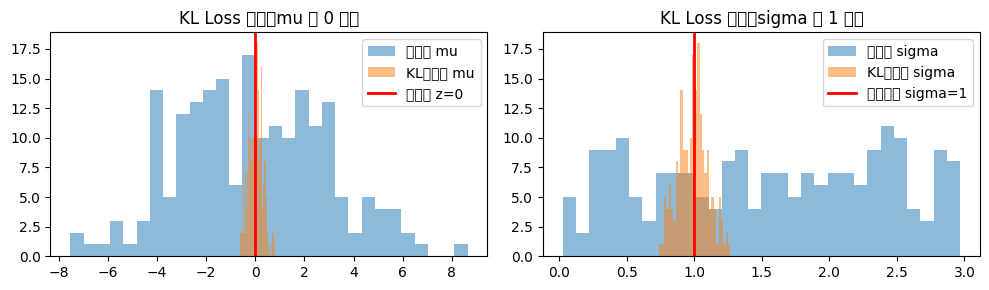

推理时为什么用 z=0？
  KL 约束让 mu → 0, sigma → 1
  z=0 相当于从训练分布的中心取样，是最'通用'的动作风格


In [11]:
# 可视化：训练时 z 和推理时 z=0 的差异
import matplotlib.pyplot as plt
import torch

# 模拟训练时的 mu 分布（随机初始化的网络，mu 值比较散）
# KL loss 训练后会把 mu 往 0 拉，sigma 往 1 拉
torch.manual_seed(42)
mu_before   = torch.randn(200, 32) * 3    # 训练前：mu 散开
sigma_before = torch.rand(200, 32) * 3    # 训练前：sigma 乱

mu_after    = torch.randn(200, 32) * 0.3  # 训练后（KL 约束）：mu 靠近 0
sigma_after = torch.ones(200, 32) * 1.0 + torch.randn(200, 32) * 0.1  # sigma 靠近 1

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(mu_before[:, 0].numpy(), bins=30, alpha=0.5, label="训练前 mu")
axes[0].hist(mu_after[:, 0].numpy(),  bins=30, alpha=0.5, label="KL约束后 mu")
axes[0].axvline(0, color="red", lw=2, label="推理时 z=0")
axes[0].set_title("KL Loss 效果：mu 往 0 靠拢")
axes[0].legend()

axes[1].hist(sigma_before[:, 0].numpy(), bins=30, alpha=0.5, label="训练前 sigma")
axes[1].hist(sigma_after[:, 0].numpy(),  bins=30, alpha=0.5, label="KL约束后 sigma")
axes[1].axvline(1, color="red", lw=2, label="标准正态 sigma=1")
axes[1].set_title("KL Loss 效果：sigma 往 1 靠拢")
axes[1].legend()
plt.tight_layout()
plt.show()

print("推理时为什么用 z=0？")
print("  KL 约束让 mu → 0, sigma → 1")
print("  z=0 相当于从训练分布的中心取样，是最'通用'的动作风格")


### 重参数化技巧（Reparameterization Trick）

核心问题：**怎么对随机采样 `z ~ N(mu, sigma²)` 求梯度？**

直接采样无法反向传播，因为随机操作没有梯度。重参数化的思路：

```
# 直接采样（不可求导）
z ~ N(mu, sigma²)   ← 随机节点，梯度断了

# 重参数化（可求导）
epsilon ~ N(0, I)    ← 与网络无关的随机数
z = mu + sigma * epsilon   ← mu 和 sigma 是网络输出，可以求导！
```

```mermaid
flowchart LR
  NET["网络输出\nmu, log_sigma²"] --> CALC["z = mu + exp(log_sigma²/2) * ε"]
  RAND["ε ~ N(0,I)\n（与网络无关）"] --> CALC
  CALC --> Z["z [B,32]"]
  Z --> NEXT["送入主 Transformer"]
  style NET fill:#1a3a5c,color:#c9d1d9
  style RAND fill:#2d2d2d,color:#c9d1d9
```

代码里对应：
```python
# modeling_act.py 第 449 行
latent_sample = mu + log_sigma_x2.div(2).exp() * torch.randn_like(mu)
#                ↑             ↑                        ↑
#               mu         sigma=exp(logσ²/2)          ε
```


In [ ]:
# 演示重参数化可以让梯度流回 mu/sigma
import torch

mu        = torch.tensor([1.0, 2.0], requires_grad=True)
log_sig2  = torch.tensor([0.0, 0.0], requires_grad=True)  # log_sigma²=0 → sigma=1

epsilon   = torch.randn(2)  # 与网络无关
z         = mu + log_sig2.div(2).exp() * epsilon  # 重参数化

loss = z.sum()  # 随便定个 loss
loss.backward()

print("mu.grad      :", mu.grad)      # 有梯度 → 可以优化 mu
print("log_sig2.grad:", log_sig2.grad) # 有梯度 → 可以优化 sigma
print("✅ 重参数化后，mu 和 sigma 都能正常求梯度")


### KL Loss 究竟算的是什么

**KL 散度** 衡量「VAE 编出的分布 q(z|s,a)」和「标准正态 p(z)=N(0,I)」之间的差距。

有解析公式（当两个都是正态分布时）：

```
KL = -0.5 * Σ(1 + log_sigma² - mu² - sigma²)
```

对应代码第 154-155 行：
```python
mean_kld = (-0.5 * (1 + log_sigma_x2_hat - mu_hat.pow(2) - (log_sigma_x2_hat).exp())).sum(-1).mean()
```

**直觉理解**：
- `mu² → 0`：拉着 mu 往 0 走  
- `sigma² → 1`：拉着 sigma 往 1 走  
- 这样推理时用 `z=0` 就落在训练分布的中心，不会产生 out-of-distribution 行为


In [ ]:
# 手算 KL loss，验证和公式一致
import torch

B, latent_dim = 2, 32
mu          = torch.zeros(B, latent_dim)   # mu=0 时 KL 最小
log_sigma2  = torch.zeros(B, latent_dim)   # log_sigma²=0 → sigma=1，此时 KL=0

kl = (-0.5 * (1 + log_sigma2 - mu.pow(2) - log_sigma2.exp())).sum(-1).mean()
print("mu=0, sigma=1 时 KL:", kl.item(), "  ← 应该等于 0")

mu2         = torch.ones(B, latent_dim) * 3   # mu 偏离 0
log_sigma2b = torch.zeros(B, latent_dim)
kl2 = (-0.5 * (1 + log_sigma2b - mu2.pow(2) - log_sigma2b.exp())).sum(-1).mean()
print("mu=3, sigma=1 时 KL:", kl2.item(), "  ← mu 偏离越大，KL 越大")

# 因此总 Loss = L1 + 10 * KL，KL 权重 10 保证 z 不会太偏离 N(0,1)
print("\n总 Loss = L1 + kl_weight * KL，kl_weight 默认 =", 10)


### 小结：VAE Encoder 的作用

| | 无 VAE | 有 VAE |
|---|---|---|
| 多种演示风格 | 取平均 → 走中间 → 失败 | 用 z 区分 → 选一种风格 → 成功 |
| 训练时 z | 恒为 0 | 从 action chunk 编码得到 |
| 推理时 z | 恒为 0 | 也用 0（KL 保证 0 有意义） |
| Loss | 只有 L1 | L1 + 10×KL |


### Step 6 · 反向传播 + 优化器

来自 `lerobot_train.py`：

```python
# 每个 step
batch = next(dl_iter)          # 从 DataLoader 取 batch
batch = preprocessor(batch)    # normalize
loss, _ = policy.forward(batch)
loss.backward()
clip_grad_norm_(policy.parameters(), grad_clip_norm)
optimizer.step()               # AdamW, lr=1e-5
optimizer.zero_grad()
```

推荐训练 `steps=80000`，batch_size=8，在 MPS/CUDA 上约几小时。

---
### Step 7 · 推理（Inference）

推理时 **不用 VAE Encoder**，直接把 `z=0` 送进去：

```
image + state → Backbone + Encoder → Decoder → [100, 2] action chunk
取前 n_action_steps=100 步执行，下一帧再 re-query
```
